# Analysis of the synoptic flow regimes around Taiwan using TaiESM1# 
分析TaiEMS1的綜觀流場需要完成以下幾件事情:
1. 時間挑選在historical跟ssp585的情境下，挑選2年(2010-2011,2099-2100)把10月到4月的資料擷取出來
2. 篩選空間範圍為東亞的區域:100E-150E,10N-50N
3. 將使用每天的地面氣壓場、降水、1000 hPa風場
4. 選取石垣島周邊一定範圍計算風向的變異程度作為指標
5. 將台灣含括在內的一定範圍計算降水網格數量的比例
6. 畫出地面天氣圖並上述兩指標標示在圖上後，診斷該日是否符合local circulation dimunated days(延伸議題:此一天數變化與ENSO之類的interannual訊號之關聯?)


In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
from glob import glob
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
%matplotlib inline

def uv2deg(ser):
    if ser.u1000==0:
        return 180.0 if ser.v1000>0 else 0.0
    else:
        tmpdir=270-np.arctan(ser.v1000/ser.u1000)/np.pi*180
        return tmpdir if ser.u1000>0 else tmpdir-180
ishigaki={'lat':24.33,'lon':124.16}
subplot_kws=dict(projection=ccrs.PlateCarree(central_longitude=180))

In [2]:
dataDir='/data/mileshsieh/CMIP6'
m='TaiESM1'
scenarios=['historical','ssp126','ssp245','ssp370','ssp585']

template='%s/%s/%s/atmos/day/r1i1p1f1/%s_day_%s_%s_r1i1p1f1_gn_%04d0101-*.nc'
varList=['psl','ua','va','pr']

In [3]:
[min_lon, max_lon, min_lat, max_lat]=[100.,150.,10.,50.]
yrDict={'historical':[2010,'2010-01-01','2011-12-31'],'ssp585':[2095,'2099-01-01','2100-12-31']} #[start yr of files,stat_start_date,stat_end_date]
p_selected=1000

dsDict={}
#open mfdataset (multiple files dataset)
for sce in yrDict.keys():
    yr_start=yrDict[sce][0]
    #open multiple files
    fList=[glob(template%(dataDir,m,sce,var,m,sce,yr_start))[0] for var in varList]
    #print(len(fList),fList)
    #open multiple files
    dsDict[sce]=xr.open_mfdataset(fList).sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon),
                                             time=slice(yrDict[sce][1], yrDict[sce][2]),plev=p_selected*100)

In [4]:
#test of calculate precipitation areas
[min_lon_tw, max_lon_tw, min_lat_tw, max_lat_tw]=[118,126,22,26]
prec_threshold=0.1
def cold_season(month):
    return (month <= 4) | (month >= 10)

[min_lon_ish, max_lon_ish, min_lat_ish, max_lat_ish]=[122,126,22,26]

def uv2ws(u, v):
    func = lambda x, y: np.sqrt(x**2 + y**2)
    return xr.apply_ufunc(func, u, v,dask="allowed")

def uv2wd(u, v):
    func = lambda x,y: np.where(u==0,np.where(v>0,180.0,0.0),180.0 + np.arctan2(u, v) * 180.0 / np.pi)
    return xr.apply_ufunc(func, u, v,dask="allowed")

def calc_wd_cor(wd_array):
    wd_min=wd_array.min()
    #print(wd_min)
    wdList=np.array([dd-wd_min if abs(dd-wd_min)<180.0 else wd_min-(dd-360.0) for dd in wd_array.ravel()])
    result=np.percentile(wdList,75)
    return result

#sce='historical'
#dateStr='1991-01-01'
dfDict={}
for sce in ['historical','ssp585']:
#for sce in ['historical','ssp585']:
  #ish_ds=dsDict['historical'].sel(lat=slice(min_lat_ish,max_lat_ish),lon=slice(min_lon_ish,max_lon_ish),time=dateStr)
    tw_ds=dsDict[sce].sel(lat=slice(min_lat_tw,max_lat_tw),lon=slice(min_lon_tw,max_lon_tw),time=cold_season(dsDict[sce]['time.month']))
    #convert to mm/hr
    #kgm-2s-1 /998 kgm-3 *3600*1000 = mm/hr
    tw_ds['prect']=tw_ds.pr*3600
    tw_ds['prRatio']=tw_ds.prect.where(tw_ds.prect>=prec_threshold).count(dim=['lon','lat'])/30.0
    df_tw=pd.DataFrame({'date':tw_ds.time.values,'prRatio':tw_ds.prRatio.values})
    
    ish_ds=dsDict[sce].sel(lat=slice(min_lat_ish,max_lat_ish),lon=slice(min_lon_ish,max_lon_ish),time=cold_season(dsDict[sce]['time.month']))
    ish_ds['ws']=uv2ws(ish_ds.ua, ish_ds.va)
    ish_ds['wd']=uv2wd(ish_ds.ua, ish_ds.va)
    #ish_ds['wd_p90']=ish_ds.wd.reduce(np.percentile, q=90,dim=['lat','lon'])
    #ish_ds['wd_p10']=ish_ds.wd.reduce(np.percentile, q=10,dim=['lat','lon'])
    #ish_ds['wdCor_raw']=ish_ds.wd_p90-ish_ds.wd_p10
    #ish_ds['wdCor']=ish_ds.wdCor_raw.where(ish_ds.wdCor_raw<180,360-ish_ds.wdCor_raw)
    ish_ds['wdCor']=xr.apply_ufunc(calc_wd_cor,ish_ds.wd,input_core_dims=[['lat','lon']],
                                   output_core_dims=[[]],vectorize=True)
    dateStr=ish_ds.wdCor.idxmax(dim='time').dt.strftime('%Y-%m-%d').item()
    print(dateStr,ish_ds.wdCor.max().item())
    #save to dataframe
    yyyymmdd=ish_ds.time.dt.strftime('%Y%m%d')
    u_ish=ish_ds.ua.interp(lat=ishigaki['lat'],lon=ishigaki['lon']).values
    v_ish=ish_ds.va.interp(lat=ishigaki['lat'],lon=ishigaki['lon']).values
    wdCor=ish_ds.wdCor.values
    df_ish=pd.DataFrame({'date':ish_ds.time.values,'yyyymmdd':yyyymmdd,'u1000':u_ish,'v1000':v_ish,'wdCor':wdCor})
    df_ish['wd1000']=df_ish.apply(uv2deg,axis=1)
    df_ish['ws1000']=df_ish.apply(lambda ser: np.sqrt(ser.u1000*ser.u1000+ser.v1000*ser.v1000),axis=1)
    df_ish['year']=df_ish.apply(lambda ser: ser.date.year,axis=1)
    df_ish['month']=df_ish.apply(lambda ser: ser.date.month,axis=1)
    final=pd.merge(df_ish,df_tw,on='date')
    st=final.yyyymmdd.iloc[0]
    et=final.yyyymmdd.iloc[-1]
    final.to_csv('../data/flow_regime.wind%d.%s.%s.%sto%s.csv'%(p_selected,m,sce,st,et),index=False)    
    dfDict[sce]=final

2010-01-31 168.71540069580078
2099-04-21 173.85342407226562


2010-04-11 0.0 12.540016174316406


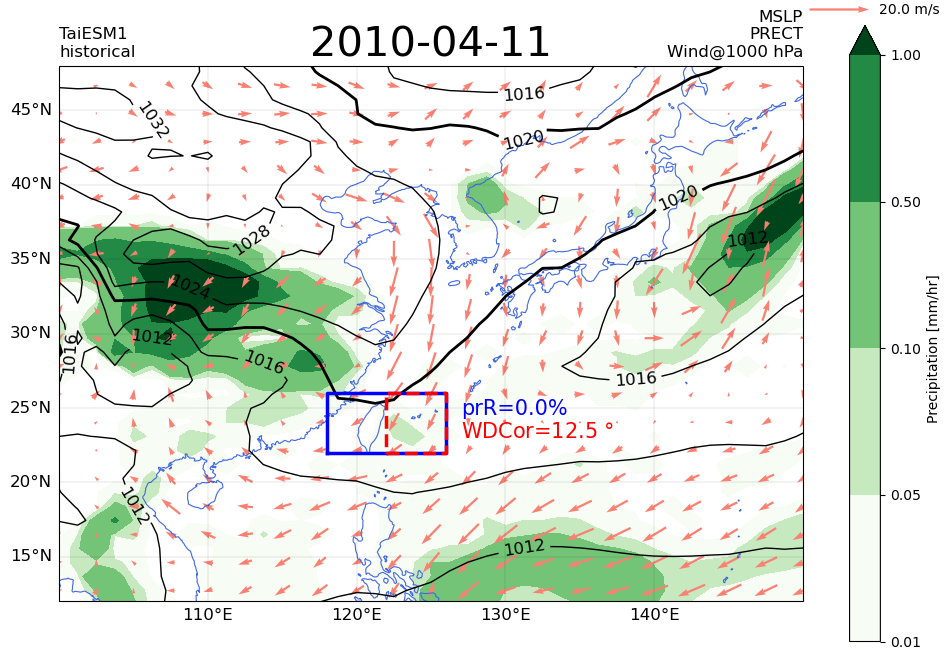

In [8]:
#single plot
[min_lon_plot, max_lon_plot, min_lat_plot, max_lat_plot]=[100.,150.,12.,48.]

slp_levels=np.linspace(980,1040,16)
slp_lws=[2 if (pp-980)%20==0 else 1 for pp in slp_levels]

sce='historical'
dd=dsDict[sce].time.values[100]
dateStr=dd.strftime('%Y-%m-%d')
prR=dfDict[sce][dfDict[sce].date==dd].prRatio.values[0]
wdCor=dfDict[sce][dfDict[sce].date==dd].wdCor.values[0]
print(dateStr,prR,wdCor)

ds_plot=dsDict[sce].sel(time=dateStr).squeeze()
msl=ds_plot.psl/100
msl.attrs = ds_plot.psl.attrs
msl.attrs['units']='hPa'

prect=ds_plot.pr*1000/998*3600 #mm/hr
prect.attrs = ds_plot.pr.attrs
prect.attrs['units']='mm/hr'

resample = ds_plot.isel(lon=slice(None, None, 2),lat=slice(None, None, 2))
# Defining the figure
fig = plt.figure(figsize=(12,8), facecolor='w', edgecolor='k')

# Axes with Cartopy projection
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
# and extent
ax.set_extent([min_lon_plot, max_lon_plot, min_lat_plot, max_lat_plot], ccrs.PlateCarree())

# Plotting using Matplotlib the mean current
cs_p = prect.plot.contourf(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.5,1.0],extend='max',cmap='Greens',transform=ccrs.PlateCarree())
#cs_p2 = prect.plot.contour(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.5,1.0],cmap='hot_r',linewidths=1.2,transform=ccrs.PlateCarree())
cs = msl.plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=slp_levels,
                      colors='k',
                      linewidths=slp_lws)
q1=resample.plot.quiver(ax=ax,x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(),
                        scale=250,color='salmon',width=0.003,add_guide=False)

ax.clabel(cs, slp_levels, inline=True, fmt='%.0f', fontsize=12)
#ax.clabel(cs_p2, [0.01,0.05,0.1,0.5,1.0], inline=True, fmt='%.2f', fontsize=12)
#q1=ds_plot.plot.quiver(x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(), scale=80,color='g')
ax.coastlines(resolution='50m',linewidth=0.8,color='royalblue')
# Plot lat/lon grid 
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1, 
                  linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12} 

ax.plot([min_lon_tw, max_lon_tw,max_lon_tw,min_lon_tw,min_lon_tw],\
        [min_lat_tw,min_lat_tw, max_lat_tw,max_lat_tw,min_lat_tw],\
        lw=2.5,color='b',transform=ccrs.PlateCarree())
ax.plot([min_lon_ish, max_lon_ish,max_lon_ish,min_lon_ish,min_lon_ish],\
        [min_lat_ish,min_lat_ish, max_lat_ish,max_lat_ish,min_lat_ish],\
        lw=2.5,ls='--',color='r',transform=ccrs.PlateCarree())

ax.set_title(dateStr,fontsize=30)
ax.set_title('TaiESM1\n%s'%sce,fontsize=12,loc='left')
ax.set_title('MSLP\nPRECT\nWind@1000 hPa',fontsize=12,loc='right')
ax.text(max_lon_tw+1,max_lat_tw-1.5,'prR=%.1f%%'%(prR*100),color='b',fontsize=15,transform=ccrs.PlateCarree())
ax.text(max_lon_tw+1,min_lat_tw+1,'WDCor=%.1f $\degree$'%wdCor,color='r',fontsize=15,transform=ccrs.PlateCarree())
# Vector options declaration
veclenght = 20
maxstr = '%3.1f m/s' % veclenght
plt.quiverkey(q1,0.8,0.9,veclenght,maxstr,labelpos='E', coordinates='figure').set_zorder(11)
plt.savefig('../weatherMap/%s.%s_%s.png'%(m,sce,dateStr))


2010-01-01 0.0 17.16851043701172
2010-01-02 0.0 14.073394775390625
2010-01-03 0.0 36.94244384765625
2010-01-04 0.0 22.074974060058594
2010-01-05 0.0 3.536235809326172
2010-01-06 3.3333333333333335 5.565071105957031
2010-01-07 10.0 8.514549255371094
2010-01-08 3.3333333333333335 22.99469757080078
2010-01-09 50.0 19.22522735595703
2010-01-10 70.0 34.41273498535156
2010-01-11 6.666666666666667 30.75787353515625
2010-01-12 0.0 22.777915954589844
2010-01-13 0.0 21.738739013671875
2010-01-14 0.0 12.389873504638672
2010-01-15 0.0 28.815582275390625
2010-01-16 3.3333333333333335 83.0797348022461
2010-01-17 13.333333333333334 13.558822631835938
2010-01-18 0.0 5.3692169189453125
2010-01-19 10.0 12.388648986816406
2010-01-20 36.666666666666664 45.48268127441406
2010-01-21 43.333333333333336 17.32251739501953
2010-01-22 23.333333333333332 16.887733459472656
2010-01-23 26.666666666666668 18.689979553222656
2010-01-24 0.0 25.09638214111328
2010-01-25 0.0 20.903465270996094
2010-01-26 10.0 37.6925811

2010-12-30 0.0 28.469493865966797
2010-12-31 26.666666666666668 18.070316314697266
2011-01-01 43.333333333333336 14.829910278320312
2011-01-02 23.333333333333332 137.02969360351562
2011-01-03 100.0 80.80871200561523
2011-01-04 33.33333333333333 18.96747589111328
2011-01-05 0.0 35.763916015625
2011-01-06 0.0 31.448265075683594
2011-01-07 0.0 20.915786743164062
2011-01-08 0.0 79.98880004882812
2011-01-09 0.0 68.49107360839844
2011-01-10 60.0 40.512603759765625
2011-01-11 96.66666666666667 110.83160400390625
2011-01-12 60.0 8.667816162109375
2011-01-13 26.666666666666668 4.359245300292969
2011-01-14 66.66666666666666 10.110328674316406
2011-01-15 73.33333333333333 13.046810150146484
2011-01-16 56.666666666666664 115.21981811523438
2011-01-17 66.66666666666666 14.080085754394531
2011-01-18 50.0 20.594940185546875
2011-01-19 30.0 17.503829956054688
2011-01-20 6.666666666666667 11.372955322265625
2011-01-21 20.0 12.962089538574219
2011-01-22 0.0 34.986854553222656
2011-01-23 0.0 16.690269470

2011-12-22 0.0 9.835834503173828
2011-12-23 0.0 6.956390380859375
2011-12-24 0.0 19.331825256347656
2011-12-25 6.666666666666667 22.492172241210938
2011-12-26 16.666666666666664 16.689769744873047
2011-12-27 16.666666666666664 40.87312316894531
2011-12-28 30.0 17.74199676513672
2011-12-29 6.666666666666667 9.337257385253906
2011-12-30 3.3333333333333335 6.694599151611328
2011-12-31 0.0 54.949180603027344
2099-01-01 60.0 17.011573791503906
2099-01-02 83.33333333333334 7.2404022216796875
2099-01-03 40.0 7.511634826660156
2099-01-04 30.0 14.669914245605469
2099-01-05 0.0 8.307121276855469
2099-01-06 10.0 13.883209228515625
2099-01-07 16.666666666666664 26.4437255859375
2099-01-08 0.0 15.292137145996094
2099-01-09 0.0 17.396644592285156
2099-01-10 0.0 14.257499694824219
2099-01-11 0.0 14.896469116210938
2099-01-12 0.0 3.5922927856445312
2099-01-13 0.0 26.90857696533203
2099-01-14 0.0 14.59808349609375
2099-01-15 43.333333333333336 6.50408935546875
2099-01-16 50.0 15.002079010009766
2099-01

2099-12-22 73.33333333333333 56.749881744384766
2099-12-23 33.33333333333333 7.416069030761719
2099-12-24 3.3333333333333335 17.255325317382812
2099-12-25 10.0 18.64093017578125
2099-12-26 13.333333333333334 13.551078796386719
2099-12-27 3.3333333333333335 5.537967681884766
2099-12-28 0.0 26.08385467529297
2099-12-29 6.666666666666667 36.065269470214844
2099-12-30 0.0 23.262229919433594
2099-12-31 0.0 15.509445190429688
2100-01-01 30.0 41.379119873046875
2100-01-02 26.666666666666668 19.74726104736328
2100-01-03 16.666666666666664 22.08509063720703
2100-01-04 20.0 23.91295623779297
2100-01-05 23.333333333333332 27.87701416015625
2100-01-06 10.0 17.428565979003906
2100-01-07 6.666666666666667 12.25030517578125
2100-01-08 6.666666666666667 5.229640960693359
2100-01-09 20.0 11.519760131835938
2100-01-10 0.0 21.951744079589844
2100-01-11 33.33333333333333 21.771163940429688
2100-01-12 36.666666666666664 36.32288360595703
2100-01-13 3.3333333333333335 9.286285400390625
2100-01-14 0.0 25.513

2100-12-11 73.33333333333333 10.803230285644531
2100-12-12 100.0 127.85096740722656
2100-12-13 60.0 17.81121826171875
2100-12-14 53.333333333333336 35.289024353027344
2100-12-15 56.666666666666664 16.899765014648438
2100-12-16 0.0 19.648338317871094
2100-12-17 0.0 8.916187286376953
2100-12-18 13.333333333333334 10.125053405761719
2100-12-19 56.666666666666664 17.112228393554688
2100-12-20 46.666666666666664 16.581756591796875
2100-12-21 40.0 16.679115295410156
2100-12-22 20.0 19.055633544921875
2100-12-23 3.3333333333333335 11.731292724609375
2100-12-24 10.0 7.322444915771484
2100-12-25 23.333333333333332 17.18719482421875
2100-12-26 43.333333333333336 15.255386352539062
2100-12-27 13.333333333333334 12.676254272460938
2100-12-28 23.333333333333332 15.670112609863281
2100-12-29 0.0 7.964424133300781
2100-12-30 6.666666666666667 25.456192016601562
2100-12-31 13.333333333333334 25.311721801757812


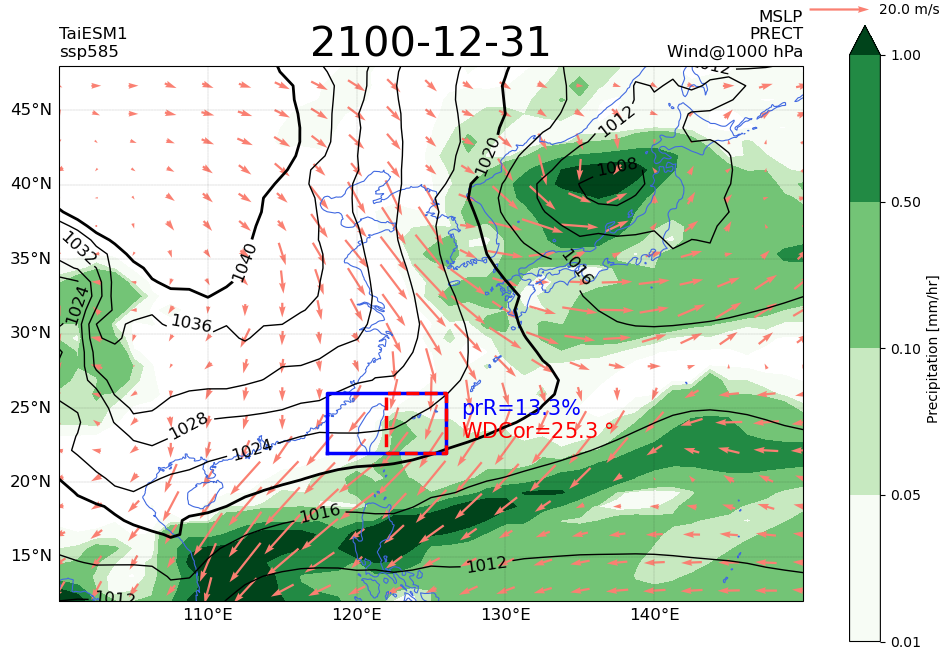

In [9]:
[min_lon_plot, max_lon_plot, min_lat_plot, max_lat_plot]=[100.,150.,12.,48.]

slp_levels=np.linspace(980,1040,16)
slp_lws=[2 if (pp-980)%20==0 else 1 for pp in slp_levels]

for sce in ['historical','ssp585']:
    for dd in dsDict[sce].sel(time=cold_season(dsDict[sce]['time.month'])).time.values:
        dateStr=dd.strftime('%Y-%m-%d')
        prR=dfDict[sce][dfDict[sce].date==dd].prRatio.values[0]
        wdCor=dfDict[sce][dfDict[sce].date==dd].wdCor.values[0]
        print(dateStr,prR*100,wdCor)
        
        ds_plot=dsDict[sce].sel(time=dateStr).squeeze()
        msl=ds_plot.psl/100
        msl.attrs = ds_plot.psl.attrs
        msl.attrs['units']='hPa'

        prect=ds_plot.pr*1000/998*3600 #mm/hr
        prect.attrs = ds_plot.pr.attrs
        prect.attrs['units']='mm/hr'

        resample = ds_plot.isel(lon=slice(None, None, 2),lat=slice(None, None, 2))
        # Defining the figure
        plt.close()
        fig = plt.figure(figsize=(12,8), facecolor='w', edgecolor='k')

        # Axes with Cartopy projection
        ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
        # and extent
        ax.set_extent([min_lon_plot, max_lon_plot, min_lat_plot, max_lat_plot], ccrs.PlateCarree())

        # Plotting using Matplotlib the mean current
        cs_p = prect.plot.contourf(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.5,1.0],extend='max',cmap='Greens',transform=ccrs.PlateCarree())
        #cs_p2 = prect.plot.contour(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.5,1.0],cmap='hot_r',linewidths=1.2,transform=ccrs.PlateCarree())
        cs = msl.plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=slp_levels,
                      colors='k',
                      linewidths=slp_lws)
        q1=resample.plot.quiver(ax=ax,x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(),
                        scale=250,color='salmon',width=0.003,add_guide=False)

        ax.clabel(cs, slp_levels, inline=True, fmt='%.0f', fontsize=12)
        #ax.clabel(cs_p2, [0.01,0.05,0.1,0.5,1.0], inline=True, fmt='%.2f', fontsize=12)
        #q1=ds_plot.plot.quiver(x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(), scale=80,color='g')
        ax.coastlines(resolution='50m',linewidth=0.8,color='royalblue')
        # Plot lat/lon grid 
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1, 
                  linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = {'size': 12}
        gl.ylabel_style = {'size': 12} 

        ax.plot([min_lon_tw, max_lon_tw,max_lon_tw,min_lon_tw,min_lon_tw],\
                [min_lat_tw,min_lat_tw, max_lat_tw,max_lat_tw,min_lat_tw],\
                lw=2.5,color='b',transform=ccrs.PlateCarree())
        ax.plot([min_lon_ish, max_lon_ish,max_lon_ish,min_lon_ish,min_lon_ish],\
                [min_lat_ish,min_lat_ish, max_lat_ish,max_lat_ish,min_lat_ish],\
                lw=2.5,ls='--',color='r',transform=ccrs.PlateCarree())

        ax.set_title(dateStr,fontsize=30)
        ax.set_title('TaiESM1\n%s'%sce,fontsize=12,loc='left')
        ax.set_title('MSLP\nPRECT\nWind@1000 hPa',fontsize=12,loc='right')
        ax.text(max_lon_tw+1,max_lat_tw-1.5,'prR=%.1f%%'%(prR*100),color='b',fontsize=15,transform=ccrs.PlateCarree())
        ax.text(max_lon_tw+1,min_lat_tw+1,'WDCor=%.1f $\degree$'%wdCor,color='r',fontsize=15,transform=ccrs.PlateCarree())
        # Vector options declaration
        veclenght = 20
        maxstr = '%3.1f m/s' % veclenght
        plt.quiverkey(q1,0.8,0.9,veclenght,maxstr,labelpos='E', coordinates='figure').set_zorder(11)
        plt.savefig('../weatherMap/%s.%s_%s.png'%(m,sce,dateStr))


In [ ]:
dateStr

In [ ]:
#some deprecated codes
#df=pd.DataFrame({'u':test_ds.ua.values.ravel(),'v':test_ds.va.values.ravel(),'ws':test_ds.ws.values.ravel(),'wd':test_ds.wd.values.ravel()})
#test_ds.sel(time=dateStr)
#print(test_ds.sel(time=dateStr).wd.max(),test_ds.sel(time=dateStr).wd.min())
#dsDict['historical'].sel(time=(dsDict['historical'].time.dt.month==10)).mean(dim='time')

#idate=np.argmax(np.max(np.max(prect,axis=-1),axis=-1))
#print(tw_ds.isel(time=idate).time,prect[idate])
#tw_day=tw_ds.isel(time=idate).time
dateStr='2010-01-19'
tw_day=tw_ds.sel(time=dateStr)

#single time snapshot of historical
sce='historical'
dateStr='1991-01-01'
[min_lon_ish, max_lon_ish, min_lat_ish, max_lat_ish]=[122,126,22,26]
ua=dsDict['historical'].sel(lat=slice(min_lat_ish,max_lat_ish),lon=slice(min_lon_ish,max_lon_ish),time=dateStr).ua.values.ravel()
va=dsDict['historical'].sel(lat=slice(min_lat_ish,max_lat_ish),lon=slice(min_lon_ish,max_lon_ish),time=dateStr).va.values.ravel()
df_area=pd.DataFrame({'u1000':ua,'v1000':va})
df_area['wd1000']=df_area.apply(uv2deg,axis=1)
df_area